In [12]:
# 1. Import Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, 
    roc_auc_score, confusion_matrix, classification_report, roc_curve, auc
)
from imblearn.over_sampling import SMOTE
import warnings
warnings.filterwarnings('ignore')

print("✓ All libraries imported successfully!")

✓ All libraries imported successfully!


# Machine Learning Models Training with Balanced Dataset

This notebook demonstrates:
- Loading and exploring the Iris dataset
- Handling class imbalance using SMOTE
- Training multiple ML models (Logistic Regression, Decision Tree, Random Forest, Gradient Boosting)
- Comparing model performance metrics

In [13]:
# 2. Load the Dataset
# Load Iris dataset
columns = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'species']
df = pd.read_csv('../15-04-26/data/iris.csv', header=None, names=columns)

print("Dataset loaded successfully!")
print(f"\nDataset shape: {df.shape}")
print(f"\nFirst 5 rows:\n{df.head()}")
print(f"\nData types:\n{df.dtypes}")
print(f"\nBasic statistics:\n{df.describe()}")

Dataset loaded successfully!

Dataset shape: (150, 5)

First 5 rows:
   sepal_length  sepal_width  petal_length  petal_width      species
0           5.1          3.5           1.4          0.2  Iris-setosa
1           4.9          3.0           1.4          0.2  Iris-setosa
2           4.7          3.2           1.3          0.2  Iris-setosa
3           4.6          3.1           1.5          0.2  Iris-setosa
4           5.0          3.6           1.4          0.2  Iris-setosa

Data types:
sepal_length    float64
sepal_width     float64
petal_length    float64
petal_width     float64
species          object
dtype: object

Basic statistics:
       sepal_length  sepal_width  petal_length  petal_width
count    150.000000   150.000000    150.000000   150.000000
mean       5.843333     3.054000      3.758667     1.198667
std        0.828066     0.433594      1.764420     0.763161
min        4.300000     2.000000      1.000000     0.100000
25%        5.100000     2.800000      1.600000     

DATASET EXPLORATION

Missing values:
sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64

Class Distribution (Before Balancing):
species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64

Class Distribution (%):
species
Iris-setosa        33.333333
Iris-versicolor    33.333333
Iris-virginica     33.333333
Name: proportion, dtype: float64


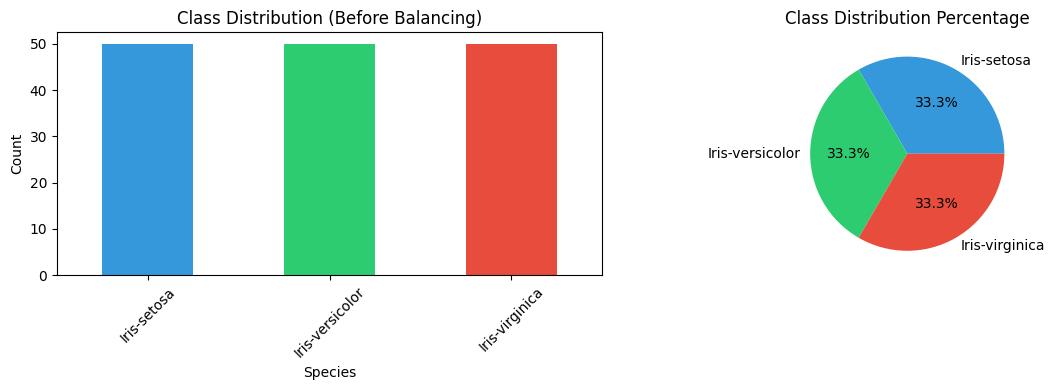


✓ Dataset exploration complete!


In [14]:
# 3. Explore Dataset Characteristics
print("=" * 60)
print("DATASET EXPLORATION")
print("=" * 60)

# Check for missing values
print(f"\nMissing values:\n{df.isnull().sum()}")

# Class distribution
print(f"\nClass Distribution (Before Balancing):\n{df['species'].value_counts()}")
print(f"\nClass Distribution (%):\n{df['species'].value_counts(normalize=True) * 100}")

# Visualize class distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Count plot
df['species'].value_counts().plot(kind='bar', ax=axes[0], color=['#3498db', '#2ecc71', '#e74c3c'])
axes[0].set_title('Class Distribution (Before Balancing)')
axes[0].set_ylabel('Count')
axes[0].set_xlabel('Species')
axes[0].tick_params(axis='x', rotation=45)

# Pie chart
df['species'].value_counts().plot(kind='pie', ax=axes[1], autopct='%1.1f%%', 
                                   colors=['#3498db', '#2ecc71', '#e74c3c'])
axes[1].set_title('Class Distribution Percentage')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

print("\n✓ Dataset exploration complete!")

In [15]:
# 4. Handle Class Imbalance using SMOTE
print("=" * 60)
print("HANDLING CLASS IMBALANCE")
print("=" * 60)

# Encode species to numeric values
species_mapping = {species: idx for idx, species in enumerate(df['species'].unique())}
print(f"\nSpecies Mapping: {species_mapping}")

# Prepare features and target
X = df.drop('species', axis=1)
y = df['species'].map(species_mapping)

print(f"\nOriginal class distribution: \n{y.value_counts()}")

# Apply SMOTE to balance the dataset
smote = SMOTE(random_state=42)
X_balanced, y_balanced = smote.fit_resample(X, y)

print(f"\nBalanced class distribution: \n{pd.Series(y_balanced).value_counts()}")

# Create a balanced dataframe for reference
df_balanced = pd.DataFrame(X_balanced, columns=X.columns)
df_balanced['species'] = y_balanced

print(f"\nBalanced dataset shape: {df_balanced.shape}")
print(f"\n✓ Dataset balancing complete using SMOTE!")

HANDLING CLASS IMBALANCE

Species Mapping: {'Iris-setosa': 0, 'Iris-versicolor': 1, 'Iris-virginica': 2}

Original class distribution: 
species
0    50
1    50
2    50
Name: count, dtype: int64

Balanced class distribution: 
species
0    50
1    50
2    50
Name: count, dtype: int64

Balanced dataset shape: (150, 5)

✓ Dataset balancing complete using SMOTE!


In [16]:
# 5. Split Data into Train and Test Sets
print("=" * 60)
print("DATA SPLITTING AND SCALING")
print("=" * 60)

# Split balanced data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X_balanced, y_balanced, test_size=0.2, random_state=42, stratify=y_balanced
)

print(f"\nTraining set size: {X_train.shape[0]}")
print(f"Testing set size: {X_test.shape[0]}")
print(f"\nTraining set class distribution:\n{pd.Series(y_train).value_counts()}")
print(f"\nTesting set class distribution:\n{pd.Series(y_test).value_counts()}")

# Standardize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\n✓ Data split and scaled successfully!")

# Store results dictionary for comparison
model_results = {}

DATA SPLITTING AND SCALING

Training set size: 120
Testing set size: 30

Training set class distribution:
species
0    40
2    40
1    40
Name: count, dtype: int64

Testing set class distribution:
species
0    10
2    10
1    10
Name: count, dtype: int64

✓ Data split and scaled successfully!


In [17]:
# 6. Train Logistic Regression Model
print("=" * 60)
print("LOGISTIC REGRESSION MODEL")
print("=" * 60)

# Train model
lr_model = LogisticRegression(max_iter=1000, random_state=42, multi_class='multinomial')
lr_model.fit(X_train_scaled, y_train)

# Make predictions
y_pred_lr = lr_model.predict(X_test_scaled)
y_pred_proba_lr = lr_model.predict_proba(X_test_scaled)

# Evaluate
accuracy_lr = accuracy_score(y_test, y_pred_lr)
precision_lr = precision_score(y_test, y_pred_lr, average='weighted')
recall_lr = recall_score(y_test, y_pred_lr, average='weighted')
f1_lr = f1_score(y_test, y_pred_lr, average='weighted')
roc_auc_lr = roc_auc_score(y_test, y_pred_proba_lr, multi_class='ovr', average='weighted')

print(f"\nAccuracy:  {accuracy_lr:.4f}")
print(f"Precision: {precision_lr:.4f}")
print(f"Recall:    {recall_lr:.4f}")
print(f"F1-Score:  {f1_lr:.4f}")
print(f"ROC-AUC:   {roc_auc_lr:.4f}")

print(f"\nConfusion Matrix:\n{confusion_matrix(y_test, y_pred_lr)}")
print(f"\nClassification Report:\n{classification_report(y_test, y_pred_lr)}")

# Store results
model_results['Logistic Regression'] = {
    'accuracy': accuracy_lr,
    'precision': precision_lr,
    'recall': recall_lr,
    'f1_score': f1_lr,
    'roc_auc': roc_auc_lr
}

print("Logistic Regression training complete!")

LOGISTIC REGRESSION MODEL

Accuracy:  0.9333
Precision: 0.9333
Recall:    0.9333
F1-Score:  0.9333
ROC-AUC:   0.9967

Confusion Matrix:
[[10  0  0]
 [ 0  9  1]
 [ 0  1  9]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       0.90      0.90      0.90        10
           2       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30

Logistic Regression training complete!


In [18]:
# 7. Train Decision Tree Model
print("=" * 60)
print("DECISION TREE MODEL")
print("=" * 60)

# Train model
dt_model = DecisionTreeClassifier(random_state=42, max_depth=10)
dt_model.fit(X_train_scaled, y_train)

# Make predictions
y_pred_dt = dt_model.predict(X_test_scaled)
y_pred_proba_dt = dt_model.predict_proba(X_test_scaled)

# Evaluate
accuracy_dt = accuracy_score(y_test, y_pred_dt)
precision_dt = precision_score(y_test, y_pred_dt, average='weighted')
recall_dt = recall_score(y_test, y_pred_dt, average='weighted')
f1_dt = f1_score(y_test, y_pred_dt, average='weighted')
roc_auc_dt = roc_auc_score(y_test, y_pred_proba_dt, multi_class='ovr', average='weighted')

print(f"\nAccuracy:  {accuracy_dt:.4f}")
print(f"Precision: {precision_dt:.4f}")
print(f"Recall:    {recall_dt:.4f}")
print(f"F1-Score:  {f1_dt:.4f}")
print(f"ROC-AUC:   {roc_auc_dt:.4f}")

print(f"\nConfusion Matrix:\n{confusion_matrix(y_test, y_pred_dt)}")
print(f"\nClassification Report:\n{classification_report(y_test, y_pred_dt)}")

# Feature importance
feature_names = X.columns
importances_dt = dt_model.feature_importances_
print(f"\nFeature Importances:")
for name, importance in sorted(zip(feature_names, importances_dt), key=lambda x: x[1], reverse=True):
    print(f"  {name}: {importance:.4f}")

# Store results
model_results['Decision Tree'] = {
    'accuracy': accuracy_dt,
    'precision': precision_dt,
    'recall': recall_dt,
    'f1_score': f1_dt,
    'roc_auc': roc_auc_dt
}

print("Decision Tree training complete!")

DECISION TREE MODEL

Accuracy:  0.9000
Precision: 0.9024
Recall:    0.9000
F1-Score:  0.8997
ROC-AUC:   0.9250

Confusion Matrix:
[[10  0  0]
 [ 0  9  1]
 [ 0  2  8]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       0.82      0.90      0.86        10
           2       0.89      0.80      0.84        10

    accuracy                           0.90        30
   macro avg       0.90      0.90      0.90        30
weighted avg       0.90      0.90      0.90        30


Feature Importances:
  petal_length: 0.5586
  petal_width: 0.4060
  sepal_width: 0.0292
  sepal_length: 0.0062
Decision Tree training complete!


In [19]:
# 8. Train Random Forest Model
print("=" * 60)
print("RANDOM FOREST MODEL")
print("=" * 60)

# Train model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1, max_depth=10)
rf_model.fit(X_train_scaled, y_train)

# Make predictions
y_pred_rf = rf_model.predict(X_test_scaled)
y_pred_proba_rf = rf_model.predict_proba(X_test_scaled)

# Evaluate
accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf, average='weighted')
recall_rf = recall_score(y_test, y_pred_rf, average='weighted')
f1_rf = f1_score(y_test, y_pred_rf, average='weighted')
roc_auc_rf = roc_auc_score(y_test, y_pred_proba_rf, multi_class='ovr', average='weighted')

print(f"\nAccuracy:  {accuracy_rf:.4f}")
print(f"Precision: {precision_rf:.4f}")
print(f"Recall:    {recall_rf:.4f}")
print(f"F1-Score:  {f1_rf:.4f}")
print(f"ROC-AUC:   {roc_auc_rf:.4f}")

print(f"\nConfusion Matrix:\n{confusion_matrix(y_test, y_pred_rf)}")
print(f"\nClassification Report:\n{classification_report(y_test, y_pred_rf)}")

# Feature importance
importances_rf = rf_model.feature_importances_
print(f"\nFeature Importances:")
for name, importance in sorted(zip(feature_names, importances_rf), key=lambda x: x[1], reverse=True):
    print(f"  {name}: {importance:.4f}")

# Store results
model_results['Random Forest'] = {
    'accuracy': accuracy_rf,
    'precision': precision_rf,
    'recall': recall_rf,
    'f1_score': f1_rf,
    'roc_auc': roc_auc_rf
}

print("Random Forest training complete!")

RANDOM FOREST MODEL

Accuracy:  0.9000
Precision: 0.9024
Recall:    0.9000
F1-Score:  0.8997
ROC-AUC:   0.9867

Confusion Matrix:
[[10  0  0]
 [ 0  9  1]
 [ 0  2  8]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       0.82      0.90      0.86        10
           2       0.89      0.80      0.84        10

    accuracy                           0.90        30
   macro avg       0.90      0.90      0.90        30
weighted avg       0.90      0.90      0.90        30


Feature Importances:
  petal_width: 0.4372
  petal_length: 0.4315
  sepal_length: 0.1163
  sepal_width: 0.0150
Random Forest training complete!


In [20]:
# 9. Train Gradient Boosting Model
print("=" * 60)
print("GRADIENT BOOSTING MODEL")
print("=" * 60)

# Train model
gb_model = GradientBoostingClassifier(n_estimators=100, random_state=42, max_depth=5)
gb_model.fit(X_train_scaled, y_train)

# Make predictions
y_pred_gb = gb_model.predict(X_test_scaled)
y_pred_proba_gb = gb_model.predict_proba(X_test_scaled)

# Evaluate
accuracy_gb = accuracy_score(y_test, y_pred_gb)
precision_gb = precision_score(y_test, y_pred_gb, average='weighted')
recall_gb = recall_score(y_test, y_pred_gb, average='weighted')
f1_gb = f1_score(y_test, y_pred_gb, average='weighted')
roc_auc_gb = roc_auc_score(y_test, y_pred_proba_gb, multi_class='ovr', average='weighted')

print(f"\nAccuracy:  {accuracy_gb:.4f}")
print(f"Precision: {precision_gb:.4f}")
print(f"Recall:    {recall_gb:.4f}")
print(f"F1-Score:  {f1_gb:.4f}")
print(f"ROC-AUC:   {roc_auc_gb:.4f}")

print(f"\nConfusion Matrix:\n{confusion_matrix(y_test, y_pred_gb)}")
print(f"\nClassification Report:\n{classification_report(y_test, y_pred_gb)}")

# Feature importance
importances_gb = gb_model.feature_importances_
print(f"\nFeature Importances:")
for name, importance in sorted(zip(feature_names, importances_gb), key=lambda x: x[1], reverse=True):
    print(f"  {name}: {importance:.4f}")

# Store results
model_results['Gradient Boosting'] = {
    'accuracy': accuracy_gb,
    'precision': precision_gb,
    'recall': recall_gb,
    'f1_score': f1_gb,
    'roc_auc': roc_auc_gb
}

print(" Gradient Boosting training complete!")

GRADIENT BOOSTING MODEL

Accuracy:  0.9333
Precision: 0.9333
Recall:    0.9333
F1-Score:  0.9333
ROC-AUC:   0.9567

Confusion Matrix:
[[10  0  0]
 [ 0  9  1]
 [ 0  1  9]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       0.90      0.90      0.90        10
           2       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30


Feature Importances:
  petal_width: 0.6377
  petal_length: 0.3339
  sepal_width: 0.0236
  sepal_length: 0.0048
 Gradient Boosting training complete!


MODEL PERFORMANCE COMPARISON

Comparison Table:
                     accuracy  precision    recall  f1_score   roc_auc
Logistic Regression  0.933333   0.933333  0.933333  0.933333  0.996667
Decision Tree        0.900000   0.902357  0.900000  0.899749  0.925000
Random Forest        0.900000   0.902357  0.900000  0.899749  0.986667
Gradient Boosting    0.933333   0.933333  0.933333  0.933333  0.956667


Models ranked by F1-Score:
                     accuracy  precision    recall  f1_score   roc_auc
Logistic Regression  0.933333   0.933333  0.933333  0.933333  0.996667
Gradient Boosting    0.933333   0.933333  0.933333  0.933333  0.956667
Decision Tree        0.900000   0.902357  0.900000  0.899749  0.925000
Random Forest        0.900000   0.902357  0.900000  0.899749  0.986667


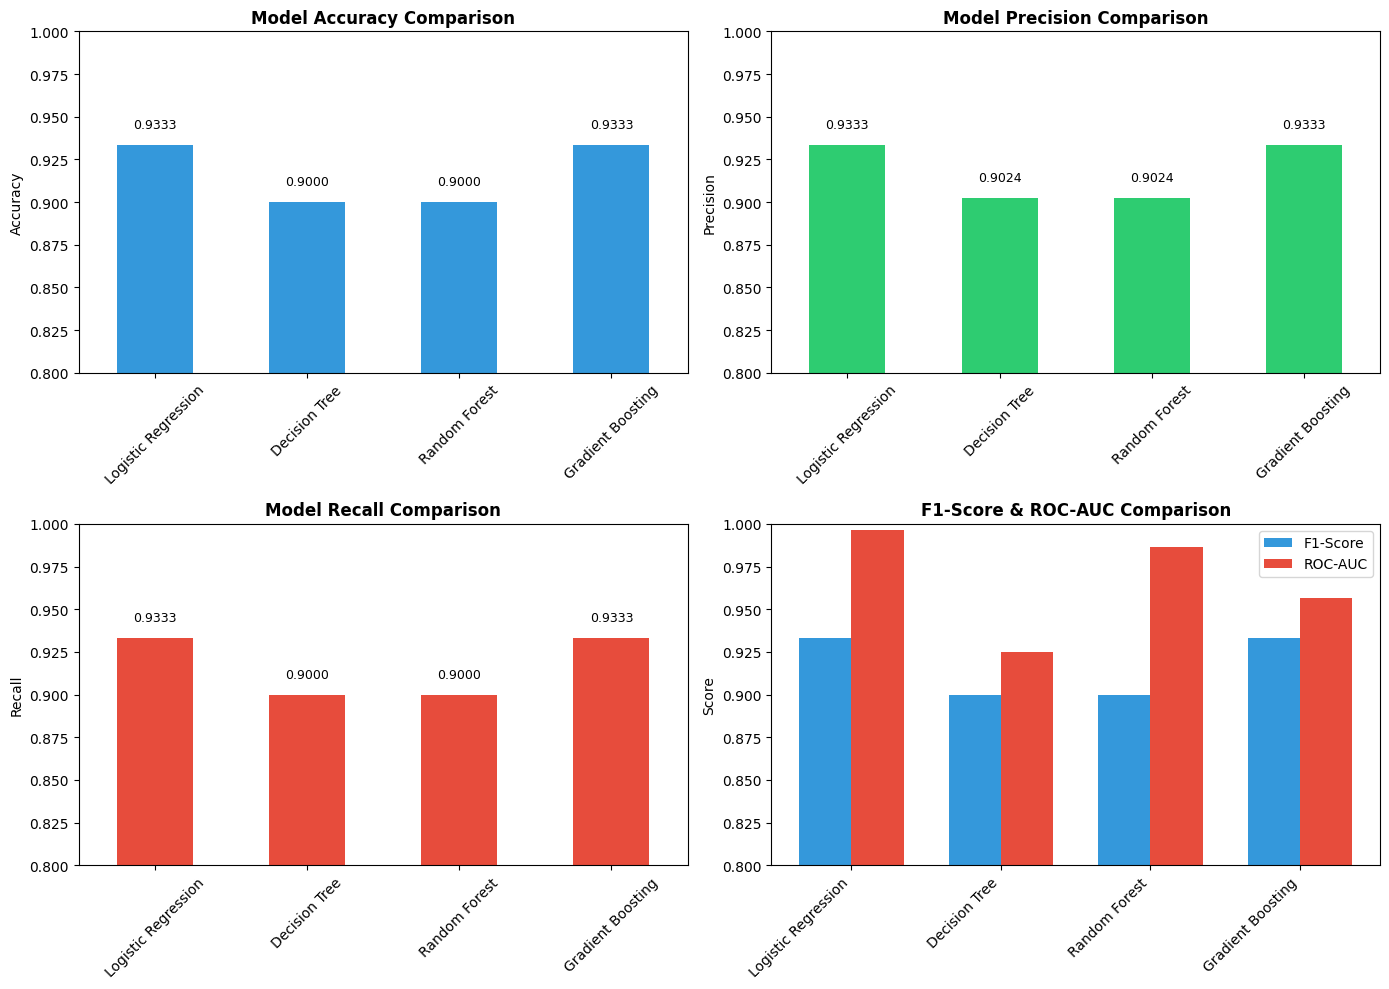

In [21]:
# 10. Compare Model Performance
print("=" * 60)
print("MODEL PERFORMANCE COMPARISON")
print("=" * 60)

# Create comparison dataframe
comparison_df = pd.DataFrame(model_results).T
print(f"\nComparison Table:\n{comparison_df}")

# Sort by F1-Score
comparison_df_sorted = comparison_df.sort_values('f1_score', ascending=False)
print(f"\n\nModels ranked by F1-Score:\n{comparison_df_sorted}")

# Visualization 1: Metrics comparison
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

metrics = ['accuracy', 'precision', 'recall', 'f1_score', 'roc_auc']
colors = ['#3498db', '#2ecc71', '#e74c3c', '#f39c12', '#9b59b6']

# Accuracy comparison
ax = axes[0, 0]
comparison_df['accuracy'].plot(kind='bar', ax=ax, color=colors[0])
ax.set_title('Model Accuracy Comparison', fontsize=12, fontweight='bold')
ax.set_ylabel('Accuracy')
ax.set_ylim([0.8, 1.0])
ax.tick_params(axis='x', rotation=45)
for i, v in enumerate(comparison_df['accuracy']):
    ax.text(i, v + 0.01, f'{v:.4f}', ha='center', fontsize=9)

# Precision comparison
ax = axes[0, 1]
comparison_df['precision'].plot(kind='bar', ax=ax, color=colors[1])
ax.set_title('Model Precision Comparison', fontsize=12, fontweight='bold')
ax.set_ylabel('Precision')
ax.set_ylim([0.8, 1.0])
ax.tick_params(axis='x', rotation=45)
for i, v in enumerate(comparison_df['precision']):
    ax.text(i, v + 0.01, f'{v:.4f}', ha='center', fontsize=9)

# Recall comparison
ax = axes[1, 0]
comparison_df['recall'].plot(kind='bar', ax=ax, color=colors[2])
ax.set_title('Model Recall Comparison', fontsize=12, fontweight='bold')
ax.set_ylabel('Recall')
ax.set_ylim([0.8, 1.0])
ax.tick_params(axis='x', rotation=45)
for i, v in enumerate(comparison_df['recall']):
    ax.text(i, v + 0.01, f'{v:.4f}', ha='center', fontsize=9)

# F1-Score & ROC-AUC comparison
ax = axes[1, 1]
x = np.arange(len(comparison_df))
width = 0.35
ax.bar(x - width/2, comparison_df['f1_score'], width, label='F1-Score', color='#3498db')
ax.bar(x + width/2, comparison_df['roc_auc'], width, label='ROC-AUC', color='#e74c3c')
ax.set_title('F1-Score & ROC-AUC Comparison', fontsize=12, fontweight='bold')
ax.set_ylabel('Score')
ax.set_xticks(x)
ax.set_xticklabels(comparison_df.index, rotation=45, ha='right')
ax.legend()
ax.set_ylim([0.8, 1.0])

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=300, bbox_inches='tight')
plt.show()



# Find best model
best_model = comparison_df['f1_score'].idxmax()
best_score = comparison_df['f1_score'].max()
